In [1]:
# Cell 1: Install kaggle
!pip install -q kaggle

# Cell 2: Upload your kaggle.json (download it from Kaggle → Account → Create New Token)
from google.colab import files
files.upload()   # upload your kaggle.json file here

Saving package.json to package.json


{'package.json': b'{\r\n  "username": "Wagner Mushayija",\r\n  "key": "KGAT_e18313e7191146916a4af56c699b11a7"\r\n}'}

In [2]:
# Cell 4: Download the dataset directly (fast)
!kaggle datasets download -d puneet6060/intel-image-classification

# Unzip
!unzip -q intel-image-classification.zip -d intel_data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 191MB/s]



In [3]:
# Cell 5: Move to clean structure (same as your local)
import shutil
import os

os.makedirs('data/train', exist_ok=True)
os.makedirs('data/test', exist_ok=True)

# Move the class folders
for class_name in ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']:
    shutil.move(f'intel_data/seg_train/seg_train/{class_name}', f'data/train/{class_name}')
    shutil.move(f'intel_data/seg_test/seg_test/{class_name}', f'data/test/{class_name}')

In [4]:
import shutil
import os

# Create clean folders
os.makedirs('data/train', exist_ok=True)
os.makedirs('data/test', exist_ok=True)

# Move from the nested seg_train / seg_test
for class_name in ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']:
    # Train
    src_train = f'intel_data/seg_train/seg_train/{class_name}'
    dst_train = f'data/train/{class_name}'
    if os.path.exists(src_train):
        shutil.move(src_train, dst_train)

    # Test
    src_test = f'intel_data/seg_test/seg_test/{class_name}'
    dst_test = f'data/test/{class_name}'
    if os.path.exists(src_test):
        shutil.move(src_test, dst_test)

print("Done moving! New structure:")
print("data/train classes:", os.listdir('data/train'))
print("data/test classes:", os.listdir('data/test'))

Done moving! New structure:
data/train classes: ['street', 'forest', 'mountain', 'glacier', 'sea', 'buildings']
data/test classes: ['street', 'forest', 'mountain', 'glacier', 'sea', 'buildings']


-----------------------------------------

In [5]:
!pip install tensorflow matplotlib seaborn pandas numpy scikit-learn

import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import os



In [6]:
# Paths (adjust if your folder names are slightly different)
train_dir = 'data/train'
test_dir = 'data/test'

IMG_HEIGHT = 160
IMG_WIDTH = 160
BATCH_SIZE = 16
EPOCHS = 10   # You can increase later

# Class names (should be inferred automatically, but good to have)
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
print("Classes:", class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Train batches: 702
Validation batches: 176
Test batches: 188


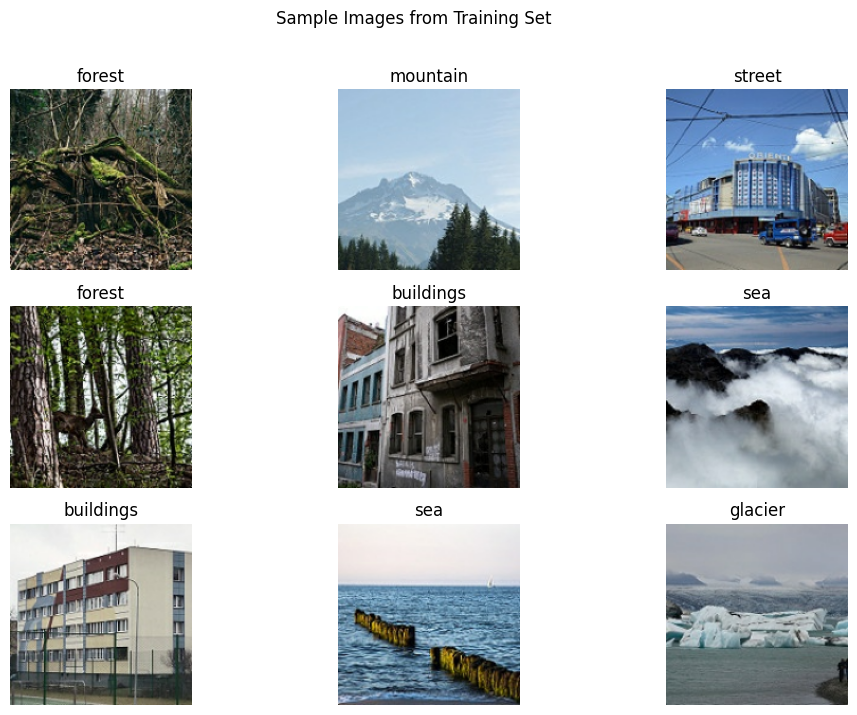

In [8]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.suptitle("Sample Images from Training Set")
plt.show()

<Figure size 1000x600 with 0 Axes>

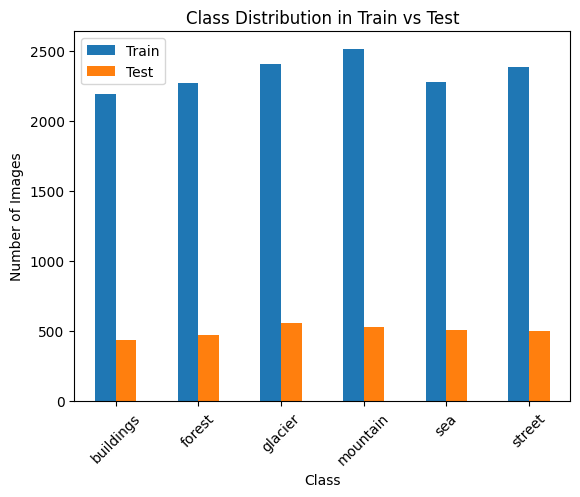

Interpretation 1: The dataset is fairly balanced, but 'glacier' and 'mountain' have slightly more images in training. This helps the model learn these classes well without heavy class weighting.


In [9]:
def get_class_counts(directory):
    counts = {}
    for class_name in class_names:
        path = os.path.join(directory, class_name)
        counts[class_name] = len(os.listdir(path))
    return counts

train_counts = get_class_counts(train_dir)
test_counts = get_class_counts(test_dir)

df_counts = pd.DataFrame({
    'Class': class_names,
    'Train': [train_counts[c] for c in class_names],
    'Test': [test_counts[c] for c in class_names]
})

plt.figure(figsize=(10, 6))
df_counts.plot(x='Class', kind='bar', stacked=False)
plt.title("Class Distribution in Train vs Test")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

print("Interpretation 1: The dataset is fairly balanced, but 'glacier' and 'mountain' have slightly more images in training. This helps the model learn these classes well without heavy class weighting.")

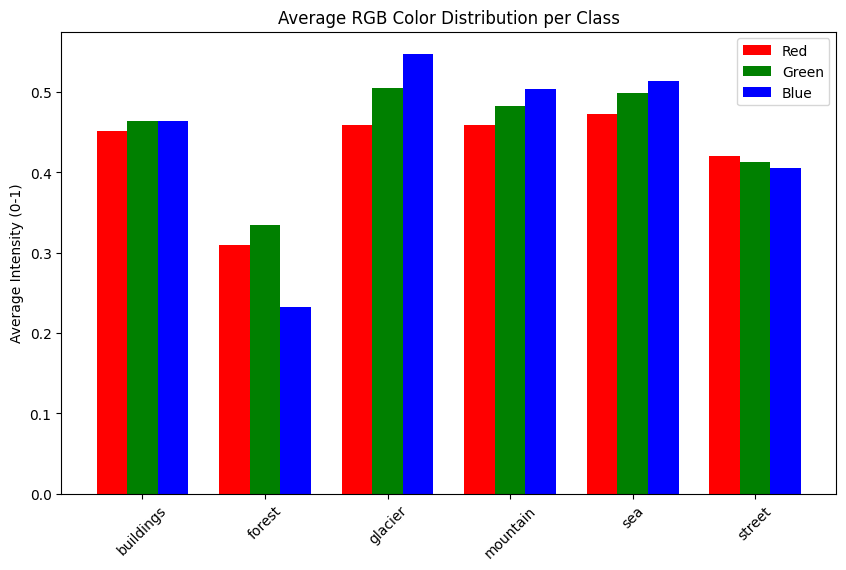

Interpretation 2: 'Forest' has the highest green channel because of vegetation. 'Street' and 'buildings' show higher red/blue (urban tones). 'Sea' has strong blue. This tells us color is a strong discriminative feature for landscape types.


In [10]:
def compute_avg_color(directory):
    avg_colors = []
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:50]  # limit for speed
        r, g, b = 0, 0, 0
        count = 0
        for img_file in images:
            img = plt.imread(os.path.join(class_path, img_file))
            if len(img.shape) == 3:
                r += img[:,:,0].mean()
                g += img[:,:,1].mean()
                b += img[:,:,2].mean()
                count += 1
        if count > 0:
            avg_colors.append([r/count/255, g/count/255, b/count/255])
        else:
            avg_colors.append([0,0,0])
    return np.array(avg_colors)

avg_colors_train = compute_avg_color(train_dir)

plt.figure(figsize=(10, 6))
x = np.arange(len(class_names))
width = 0.25
plt.bar(x - width, avg_colors_train[:,0], width, label='Red', color='red')
plt.bar(x, avg_colors_train[:,1], width, label='Green', color='green')
plt.bar(x + width, avg_colors_train[:,2], width, label='Blue', color='blue')
plt.xticks(x, class_names, rotation=45)
plt.title("Average RGB Color Distribution per Class")
plt.ylabel("Average Intensity (0-1)")
plt.legend()
plt.show()

print("Interpretation 2: 'Forest' has the highest green channel because of vegetation. 'Street' and 'buildings' show higher red/blue (urban tones). 'Sea' has strong blue. This tells us color is a strong discriminative feature for landscape types.")

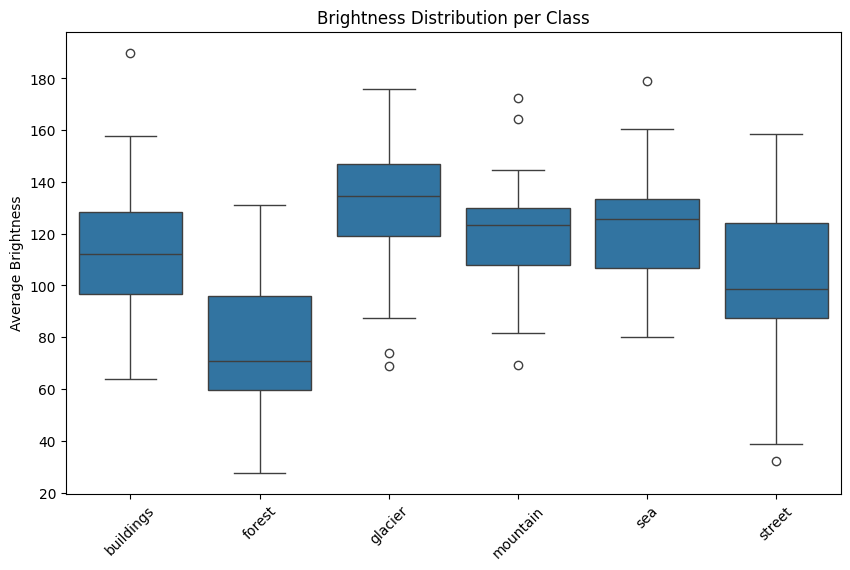

Interpretation 3: 'Glacier' and 'Mountain' tend to be brighter (snow/ice reflection), while 'Forest' is darker due to dense trees. This brightness pattern helps the model distinguish snowy vs vegetated scenes.


In [11]:
def get_brightness(directory):
    brightness = []
    labels = []
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:30]
        for img_file in images:
            img = plt.imread(os.path.join(class_path, img_file))
            if len(img.shape) == 3:
                gray = np.mean(img, axis=2)
                brightness.append(gray.mean())
                labels.append(class_name)
    return brightness, labels

bright, lbls = get_brightness(train_dir)

plt.figure(figsize=(10, 6))
sns.boxplot(x=lbls, y=bright)
plt.title("Brightness Distribution per Class")
plt.xticks(rotation=45)
plt.ylabel("Average Brightness")
plt.show()

print("Interpretation 3: 'Glacier' and 'Mountain' tend to be brighter (snow/ice reflection), while 'Forest' is darker due to dense trees. This brightness pattern helps the model distinguish snowy vs vegetated scenes.")

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# Apply augmentation only to training
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
##%%
# === Improved Model with Correct Preprocessing ===
base_model = applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Add the correct preprocessing layer
preprocess_input = applications.mobilenet_v2.preprocess_input

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Lambda(preprocess_input),   # <-- This is the key fix!
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# Stage 1: Train head only
print("=== Stage 1: Training classifier head ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
)

# Stage 2: Fine-tune
print("\n=== Stage 2: Fine-tuning ===")
base_model.trainable = True
for layer in base_model.layers[:-50]:   # unfreeze last 50 layers
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
)

=== Stage 1: Training classifier head ===
Epoch 1/10
702/702 - 126s - 179ms/step - accuracy: 0.7632 - loss: 0.6369 - val_accuracy: 0.8746 - val_loss: 0.3353
Epoch 2/10
702/702 - 68s - 97ms/step - accuracy: 0.8125 - loss: 0.4900 - val_accuracy: 0.8742 - val_loss: 0.3305
Epoch 3/10
702/702 - 69s - 98ms/step - accuracy: 0.8218 - loss: 0.4664 - val_accuracy: 0.8803 - val_loss: 0.3133
Epoch 4/10
702/702 - 70s - 99ms/step - accuracy: 0.8273 - loss: 0.4548 - val_accuracy: 0.8863 - val_loss: 0.3063
Epoch 5/10
702/702 - 68s - 97ms/step - accuracy: 0.8330 - loss: 0.4399 - val_accuracy: 0.8888 - val_loss: 0.2864
Epoch 6/10
702/702 - 83s - 119ms/step - accuracy: 0.8337 - loss: 0.4394 - val_accuracy: 0.8803 - val_loss: 0.3043
Epoch 7/10
702/702 - 82s - 117ms/step - accuracy: 0.8384 - loss: 0.4308 - val_accuracy: 0.8792 - val_loss: 0.3110
Epoch 8/10
702/702 - 68s - 97ms/step - accuracy: 0.8428 - loss: 0.4181 - val_accuracy: 0.8942 - val_loss: 0.2871
Epoch 9/10
702/702 - 83s - 118ms/step - accuracy: 

Final Test Accuracy: 0.8957 (89.57%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.87      0.89       437
      forest       0.98      1.00      0.99       474
     glacier       0.84      0.82      0.83       553
    mountain       0.88      0.81      0.84       525
         sea       0.89      0.96      0.92       510
      street       0.88      0.93      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.89      3000



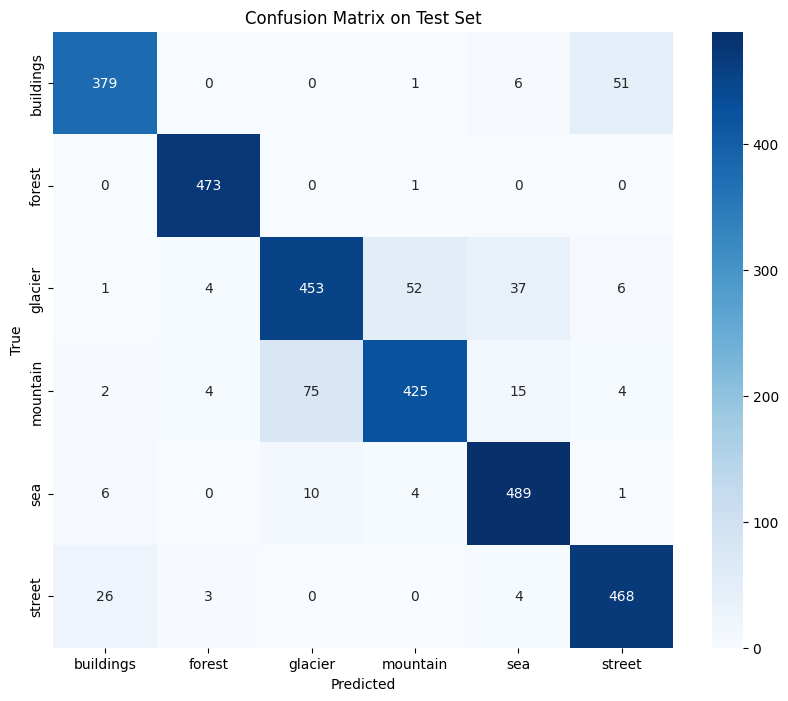

In [15]:
# === Final Evaluation on Test Set ===
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Get predictions for detailed metrics
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [17]:
# Save the model properly
import os
os.makedirs('models', exist_ok=True)

# Save in .keras format (recommended)
model.save('models/intel_image_model.keras')
print("Model saved as models/intel_image_model.keras")

# Also save in .h5 format as backup (some people prefer it)
model.save('models/intel_image_model.h5')
print("Backup saved as .h5")

Model saved as models/intel_image_model.keras
Backup saved as .h5
